# Adding Thinning to the thresholds

In [1]:
# imports
from importlib import reload
import os

import numpy as np
import h5py
import xarray
import pandas

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
import matplotlib.gridspec as gridspec
import seaborn as sns

from skimage import morphology

from wrangler.plotting import cutout
from wrangler.ogcm import llc as wr_llc

from fronts.dbof import utils as dbof_utils
from fronts.dbof import io as dbof_io
from fronts.finding import dev as finding_dev
from fronts.finding import params as finding_params
from fronts.finding import pyboa as ff_pyboa

# DBOF_dev

In [2]:
dbof_dev_file = '../fronts/runs/dbof/dev/llc4320_dbof_dev.json'

In [3]:
def plot(UID, field_data, fronts=None):
    reload(finding_dev)
    if fronts is None:
        fronts = np.zeros_like(field_data['Divb2'])
    finding_dev.front_fig6(None, fronts, field_data['Divb2'],
                                   field_data['SSTK'], field_data['b'], 
                                   field_data['DivSST2'],
                                   field_data['SSS'], field_data['DivSSS2'],
                               title=f'{UID}', show=True)

# Example

In [4]:
reload(dbof_utils)
UID_1 = 1322611708493510
field_data_1 = dbof_utils.grab_fields(dbof_dev_file, 'all', UID_1)

Read main table: /home/xavier/Projects/Oceanography/data/OGCM/DBOF/DBOF_dev/DBOF_dev.parquet
Grabbing fields for UID: 1322611708493510
Field SSSs not found for UID 1322611708493510


## Plot without fronts

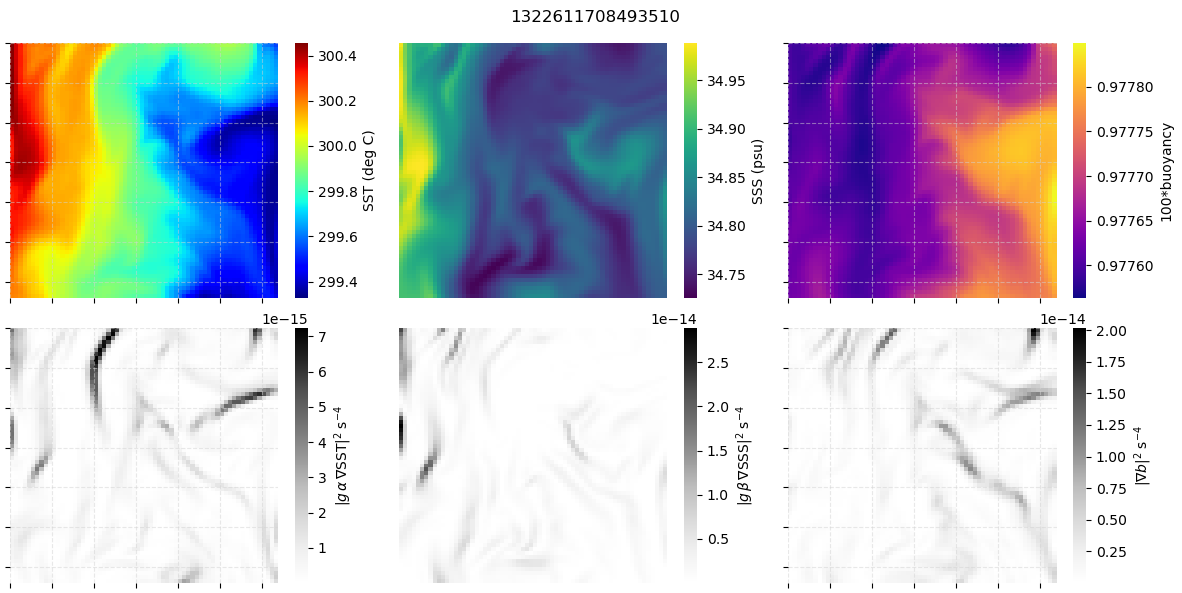

In [5]:
reload(finding_dev)
plot(UID_1, field_data_1)

# Threshold (40 pixel window, 90%)

In [6]:
fronts_40_90 = ff_pyboa.front_thresh(field_data_1['Divb2'], wndw=40, prcnt=90)
fronts_40_90 = morphology.thin(fronts_40_90)

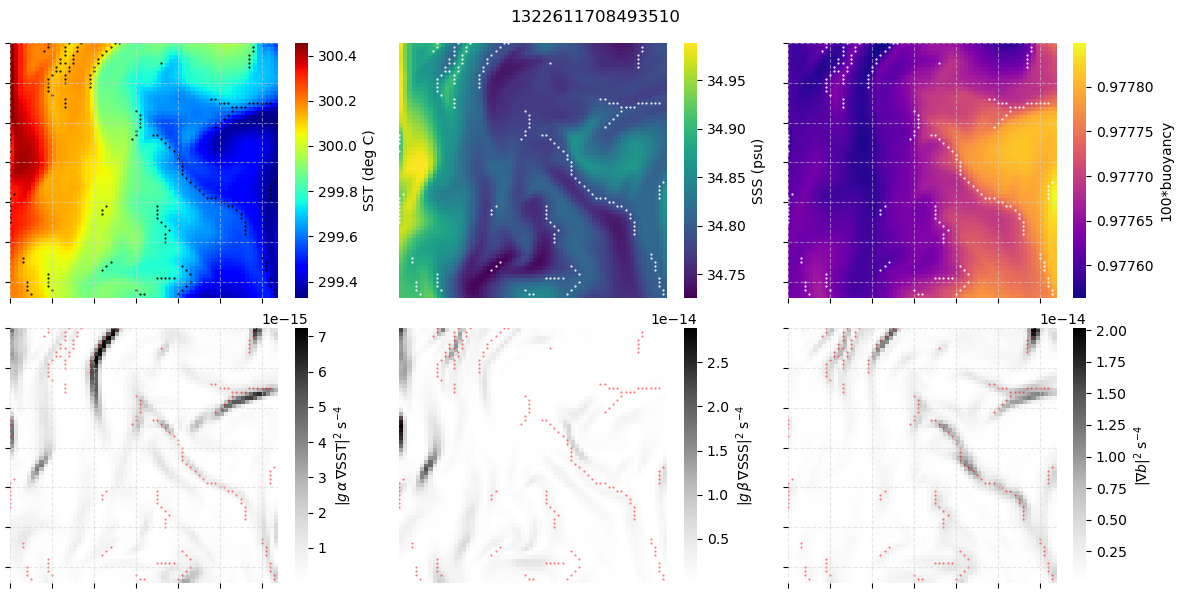

In [7]:
plot(UID_1, field_data_1, fronts=fronts_40_90)

## Lower %

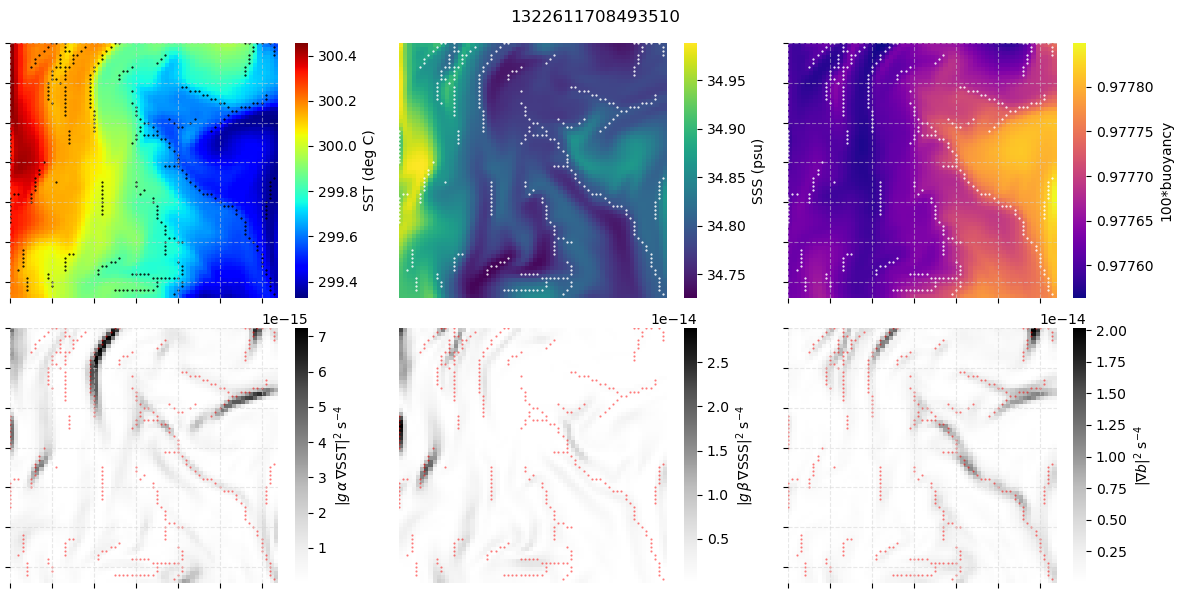

In [8]:
fronts_40_80 = ff_pyboa.front_thresh(field_data_1['Divb2'], wndw=40, prcnt=80)
fronts_40_80 = morphology.thin(fronts_40_80)
plot(UID_1, field_data_1, fronts=fronts_40_80)

## Modify window

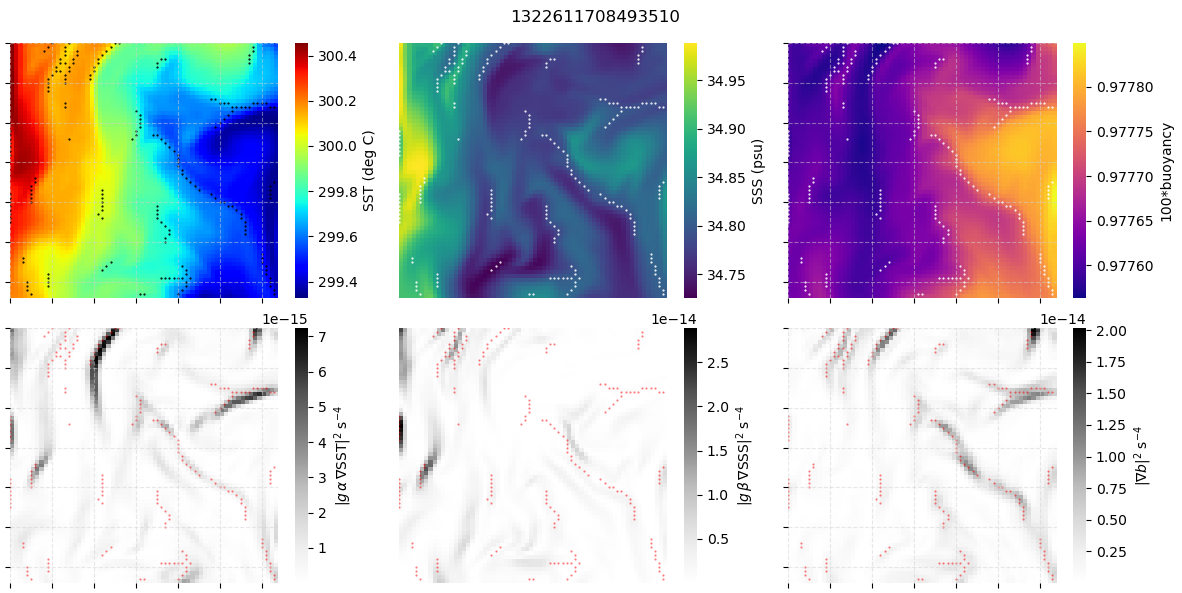

In [10]:
fronts_30_90 = ff_pyboa.front_thresh(field_data_1['Divb2'], wndw=30, prcnt=90)
fronts_30_90 = morphology.thin(fronts_30_90)
plot(UID_1, field_data_1, fronts=fronts_30_90)

## 64 pixel window

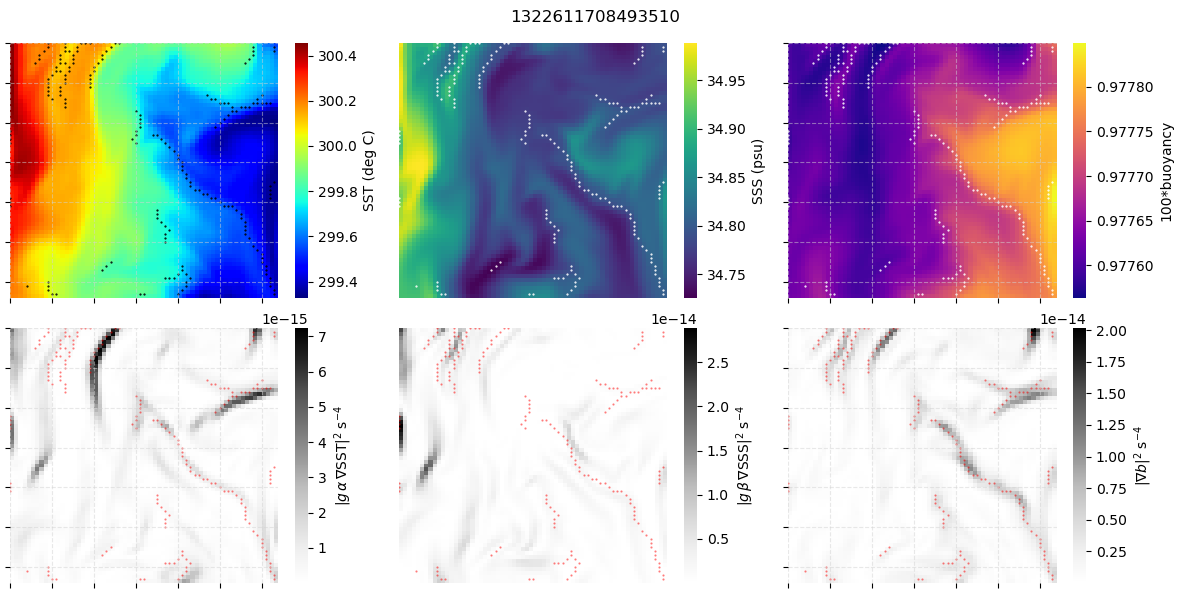

In [11]:
fronts_64_90 = ff_pyboa.front_thresh(field_data_1['Divb2'], wndw=64, prcnt=90)
fronts_64_90 = morphology.thin(fronts_64_90)
plot(UID_1, field_data_1, fronts=fronts_64_90)

## Full image, 90%

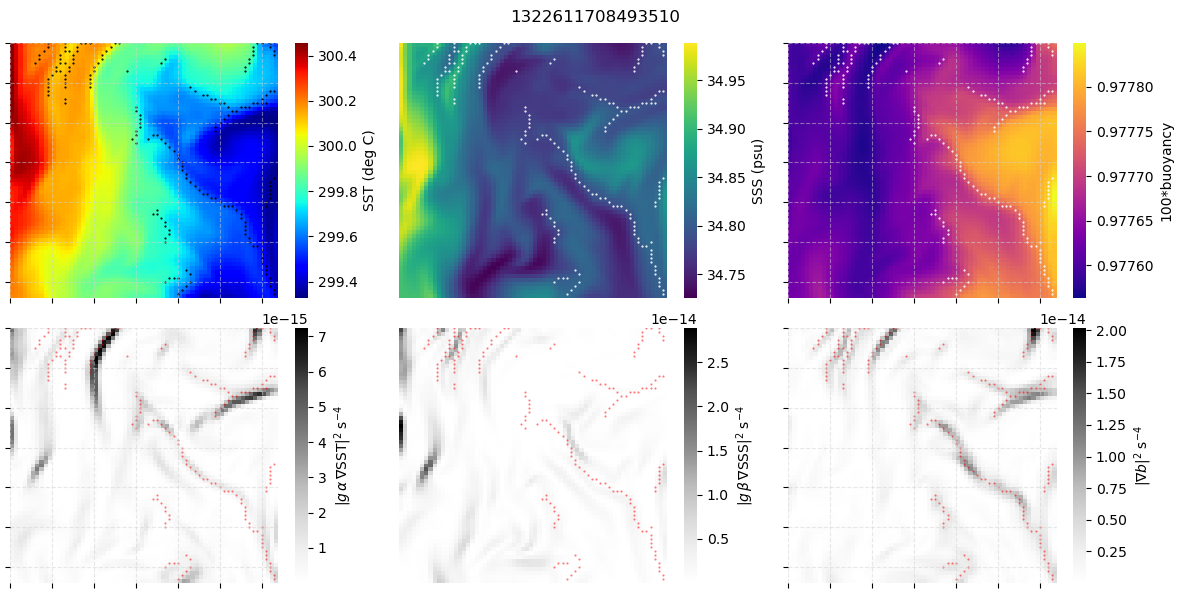

In [12]:
fronts_full_90 = ff_pyboa.global_threshold(field_data_1['Divb2'], 90.)
fronts_full_90 = morphology.thin(fronts_full_90)
plot(UID_1, field_data_1, fronts=fronts_full_90)

## Full, 80%

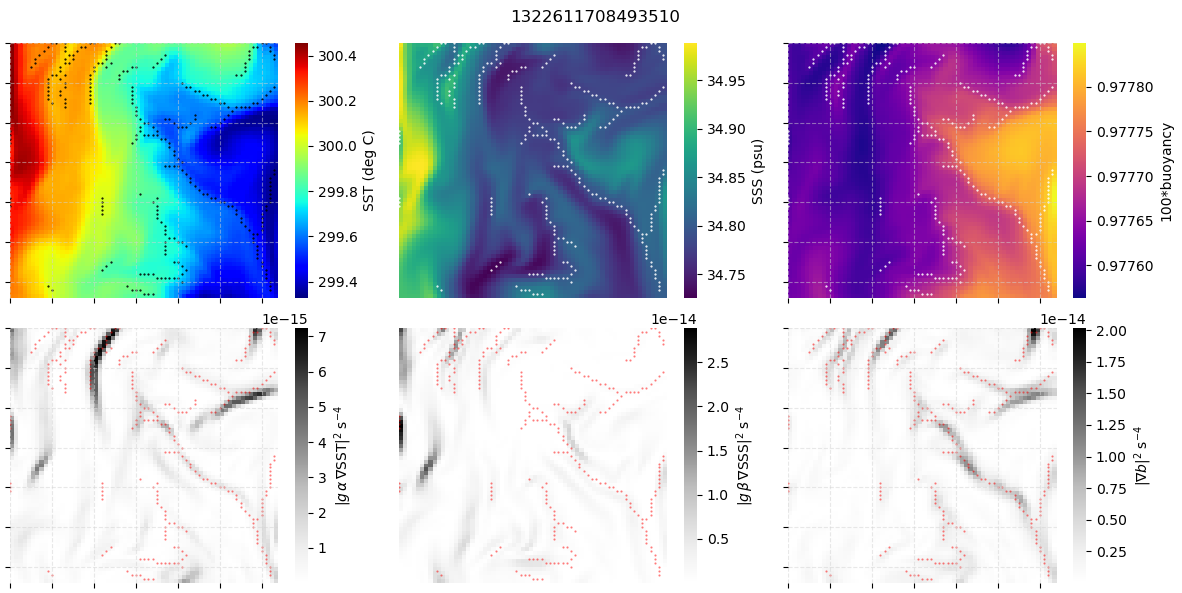

In [13]:
fronts_full_80 = ff_pyboa.global_threshold(field_data_1['Divb2'], 80.)
fronts_full_80 = morphology.thin(fronts_full_80)
plot(UID_1, field_data_1, fronts=fronts_full_80)